In [7]:
print("Hello, World!")

Hello, World!


In [8]:
import sys

print(sys.version)

3.9.6 (default, Feb  3 2024, 15:58:27) 
[Clang 15.0.0 (clang-1500.3.9.4)]


In [9]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("experiment_one")

/Users/macbook/Projects/mlops-1/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


<Experiment: artifact_location='/Users/macbook/Projects/mlops-1/02-experiment-tracking/mlruns/1', creation_time=1730890758498, experiment_id='1', last_update_time=1730890758498, lifecycle_stage='active', name='experiment_one', tags={'mlflow.note.content': 'new york taxi experiment\n'}>

In [11]:
df = pd.read_parquet('data/green_tripdata_2021-01.parquet')

In [12]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,0.5,0.5,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,0.5,0.5,2.81,0.0,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,0.5,0.5,1.00,0.0,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.0,0.5,0.5,0.00,0.0,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.0,0.0,-0.5,0.00,0.0,None,-0.3,-52.80,3.0,1.0,0.00


In [16]:
df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)

df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

In [17]:
df = df[(df.duration >= 1) & (df.duration <= 45)]



In [18]:
df.isnull().sum()

VendorID                     0
lpep_pickup_datetime         0
lpep_dropoff_datetime        0
store_and_fwd_flag       34395
RatecodeID               34395
PULocationID                 0
DOLocationID                 0
passenger_count          34395
trip_distance                0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
ehail_fee                71627
improvement_surcharge        0
total_amount                 0
payment_type             34395
trip_type                34395
congestion_surcharge     34395
duration                     0
dtype: int64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71627 entries, 0 to 76517
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               71627 non-null  int64         
 1   lpep_pickup_datetime   71627 non-null  datetime64[us]
 2   lpep_dropoff_datetime  71627 non-null  datetime64[us]
 3   store_and_fwd_flag     37232 non-null  object        
 4   RatecodeID             37232 non-null  float64       
 5   PULocationID           71627 non-null  int64         
 6   DOLocationID           71627 non-null  int64         
 7   passenger_count        37232 non-null  float64       
 8   trip_distance          71627 non-null  float64       
 9   fare_amount            71627 non-null  float64       
 10  extra                  71627 non-null  float64       
 11  mta_tax                71627 non-null  float64       
 12  tip_amount             71627 non-null  float64       
 13  tolls_

In [20]:
numerical = [ 'trip_distance', 'fare_amount', 'total_amount']
categorical = ['RatecodeID', 'PULocationID', 'DOLocationID']

df[categorical] = df[categorical].astype(str)


In [21]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.impute import SimpleImputer

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error

In [22]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

In [23]:
y_train = df.duration.values

In [24]:
model = LinearRegression()
model_2 = Lasso()
model.fit(X_train, y_train)
model_2.fit(X_train, y_train)

y_pred = model.predict(X_train)
y_pred_2 = model_2.predict(X_train)

error_1 = root_mean_squared_error(y_train, y_pred)
error_2 = mean_absolute_error(y_train, y_pred)

error_1_2 = root_mean_squared_error(y_train, y_pred_2)
error_2_2 = mean_absolute_error(y_train, y_pred_2)

print(f'RMSE_1: {error_1:.2f}')
print(f'MAE_1: {error_2:.2f}')

print(f'RMSE_2: {error_1_2:.2f}')
print(f'MAE_2: {error_2_2:.2f}')



 

RMSE_1: 5.75
MAE_1: 4.04
RMSE_2: 6.18
MAE_2: 4.46


In [36]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, model), f_out)

/var/folders/58/1jrwwbcj7mb8n97wtbklvw280000gn/T/ipykernel_62498/1505421196.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/var/folders/58/1jrwwbcj7mb8n97wtbklvw280000gn/T/ipykernel_62498/1505421196.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, lab

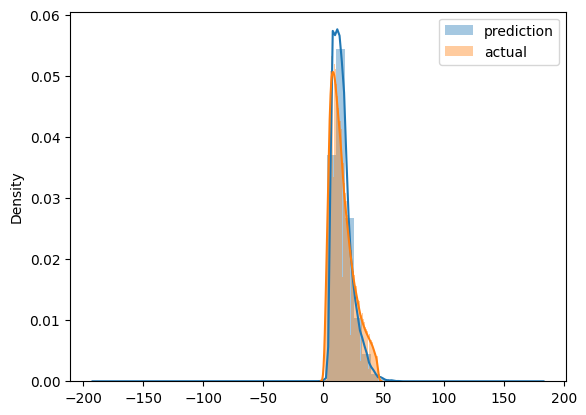

In [28]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')
plt.legend()

Now to test on validation set

In [25]:
df_val = pd.read_parquet('data/green_tripdata_2021-02.parquet')


In [26]:
categorical = ['PULocationID', 'DOLocationID'] 
numerical = [ 'trip_distance', 'fare_amount', 'total_amount']


In [27]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [28]:
df_val.lpep_dropoff_datetime = pd.to_datetime(df_val.lpep_dropoff_datetime)
df_val.lpep_pickup_datetime = pd.to_datetime(df_val.lpep_pickup_datetime)

df_val['duration'] = df_val.lpep_dropoff_datetime - df_val.lpep_pickup_datetime
df_val.duration = df_val.duration.apply(lambda td: td.total_seconds()/ 60)

In [29]:
target = 'duration'
df_val.duration = df_val.duration.fillna(df.duration.median())
y_train = df[target].values
y_val = df_val[target].values

In [31]:
with mlflow.start_run():
    alpha = 0.1 
    mlflow.set_tag('model', 'lasso')    
    
    mlflow.log_param("train_data_path", 'data/green_tripdata_2021-01.parquet')
    mlflow.log_param("val_data_path", 'data/green_tripdata_2021-02.parquet')

    mlflow.log_param("alpha", alpha)
    
    
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    mlflow.log_metric("mae", mae)

    # print(f'MAE: {mae:.2f}')

/var/folders/58/1jrwwbcj7mb8n97wtbklvw280000gn/T/ipykernel_62498/2624495092.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/var/folders/58/1jrwwbcj7mb8n97wtbklvw280000gn/T/ipykernel_62498/2624495092.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_val, label

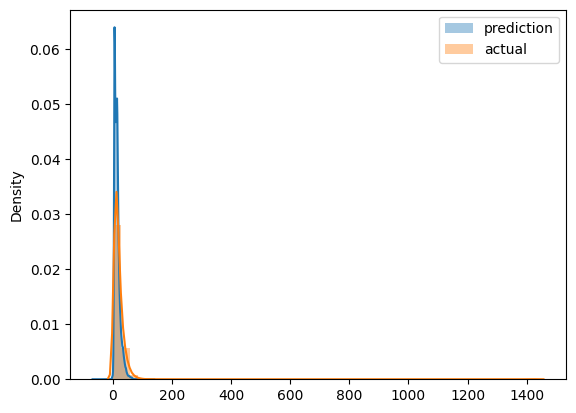

In [35]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_val, label='actual')

plt.legend()

In [32]:
import xgboost as xgb
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from hyperopt.pyll.base import scope

In [40]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [44]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag('model', 'ada_boost')
        mlflow.log_params(params)
        
        booster = xgb.train(
            params = params,
            dtrain = train,
            num_boost_round = 1000,
            evals = [(valid, 'validation')],
            early_stopping_rounds = 50,
        )
        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric('rmse', rmse)
    return {'loss': rmse, 'status': STATUS_OK}

In [45]:
search_space = {
    'maxdepth': scope.int(hp.quniform('maxdepth', 4, 100, 1)),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'reg_alpha': hp.uniform('reg_alpha', 0.01, 0.3),
    'reg_lambda': hp.uniform('reg_lambda', 0.01, 0.3),
    'min_child_weight': hp.uniform('min_child_weight', 1, 10),
    'objective': 'reg:squarederror',
    'seed': 42,
}


best_result = fmin(
    fn = objective,
    space = search_space,
    algo = tpe.suggest,
    max_evals = 50,
    trials = Trials(),
)

[0]	validation-rmse:53.17358                          
[1]	validation-rmse:52.97657                          
[2]	validation-rmse:52.82078                          
[3]	validation-rmse:52.69560                          
[4]	validation-rmse:52.59414                          
[5]	validation-rmse:52.51606                          
[6]	validation-rmse:52.45165                          
[7]	validation-rmse:52.39942                          
[8]	validation-rmse:52.36119                          
[9]	validation-rmse:52.32782                          
[10]	validation-rmse:52.30085                         
[11]	validation-rmse:52.28324                         
[12]	validation-rmse:52.26531                         
[13]	validation-rmse:52.24934                         
[14]	validation-rmse:52.23490                         
[15]	validation-rmse:52.22483                         
[16]	validation-rmse:52.22668                         
[17]	validation-rmse:52.22030                         
[18]	valid

/Users/macbook/Projects/mlops-1/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:38:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "maxdepth" } are not used.

  warnings.warn(smsg, UserWarning)



[29]	validation-rmse:52.20126                         
[30]	validation-rmse:52.20101                         
[31]	validation-rmse:52.20164                         
[32]	validation-rmse:52.20134                         
[33]	validation-rmse:52.20234                         
[34]	validation-rmse:52.20047                         
[35]	validation-rmse:52.19920                         
[36]	validation-rmse:52.19916                         
[37]	validation-rmse:52.19958                         
[38]	validation-rmse:52.19900                         
[39]	validation-rmse:52.19996                         
[40]	validation-rmse:52.19816                         
[41]	validation-rmse:52.19895                         
[42]	validation-rmse:52.19988                         
[43]	validation-rmse:52.19864                         
[44]	validation-rmse:52.19923                         
[45]	validation-rmse:52.19859                         
[46]	validation-rmse:52.19856                         
[47]	valid

/Users/macbook/Projects/mlops-1/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:38:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "maxdepth" } are not used.

  warnings.warn(smsg, UserWarning)



[27]	validation-rmse:52.17217                                                   
[28]	validation-rmse:52.17339                                                   
[29]	validation-rmse:52.17327                                                   
[30]	validation-rmse:52.17185                                                   
[31]	validation-rmse:52.17178                                                   
[32]	validation-rmse:52.17141                                                   
[33]	validation-rmse:52.17129                                                   
[34]	validation-rmse:52.16775                                                   
[35]	validation-rmse:52.16912                                                   
[36]	validation-rmse:52.16874                                                   
[37]	validation-rmse:52.16765                                                   
[38]	validation-rmse:52.16756                                                   
[39]	validation-rmse:52.1670

...

[26]	validation-rmse:52.17697                                                   
[27]	validation-rmse:52.17820                                                   
[28]	validation-rmse:52.17747                                                   
[29]	validation-rmse:52.17616                                                   
[30]	validation-rmse:52.17595                                                   
[31]	validation-rmse:52.17598                                                   
[32]	validation-rmse:52.17619                                                   
[33]	validation-rmse:52.17664                                                   
[34]	validation-rmse:52.17659                                                   
[35]	validation-rmse:52.17759                                                   
[36]	validation-rmse:52.17561                                                   
[37]	validation-rmse:52.17639                                                   
[38]	validation-rmse:52.1757

/Users/macbook/Projects/mlops-1/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:40:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "maxdepth" } are not used.

  warnings.warn(smsg, UserWarning)



[31]	validation-rmse:52.17628                                                   
[32]	validation-rmse:52.17537                                                   
[33]	validation-rmse:52.17617                                                   
[34]	validation-rmse:52.17562                                                   
[35]	validation-rmse:52.17650                                                   
[36]	validation-rmse:52.17520                                                   
[37]	validation-rmse:52.17520                                                   
[38]	validation-rmse:52.17448                                                   
[39]	validation-rmse:52.17507                                                   
[40]	validation-rmse:52.17322                                                   
[41]	validation-rmse:52.17416                                                   
[42]	validation-rmse:52.17310                                                   
[43]	validation-rmse:52.1738

/Users/macbook/Projects/mlops-1/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:40:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "maxdepth" } are not used.

  warnings.warn(smsg, UserWarning)



[23]	validation-rmse:52.27525                                                   
[24]	validation-rmse:52.27112                                                   
[25]	validation-rmse:52.26249                                                   
[26]	validation-rmse:52.25545                                                   
[27]	validation-rmse:52.24780                                                   
[28]	validation-rmse:52.24145                                                   
[29]	validation-rmse:52.23693                                                   
[30]	validation-rmse:52.23019                                                   
[31]	validation-rmse:52.22460                                                   
[32]	validation-rmse:52.22102                                                   
[33]	validation-rmse:52.21673                                                   
[34]	validation-rmse:52.21465                                                   
[35]	validation-rmse:52.2114

In [55]:
best_params = {
    "learning_rate" : 0.1753451957864083,
    "maxdepth" : 37,
    "min_child_weight" : 1.1053855276723976,
    "objective" : "reg:squarederror",
    "reg_alpha" : 0.22472040141751476,
    "reg_lambda" : 0.053634705615673774,
    "seed" : 42 
}

mlflow.log_params(best_params)


mlflow.xgboost.autolog()
booster = xgb.train(
        params = params,
        dtrain = train,
        num_boost_round = 100,
        evals = [(valid, 'validation')],
        early_stopping_rounds = 50,
        )

mlflow.xgboost.log_model(booster, artifact_path='models_mlflow')     
mlflow.log_artifact(local_path='models/lin_reg.bin', artifact_path='models_pickle')

[0]	validation-rmse:53.09050
[1]	validation-rmse:52.84924
[2]	validation-rmse:52.67027
[3]	validation-rmse:52.54132
[4]	validation-rmse:52.45270
[5]	validation-rmse:52.38411
[6]	validation-rmse:52.33418
[7]	validation-rmse:52.29414
[8]	validation-rmse:52.26673
[9]	validation-rmse:52.24291
[10]	validation-rmse:52.22715
[11]	validation-rmse:52.21336
[12]	validation-rmse:52.20813
[13]	validation-rmse:52.19851
[14]	validation-rmse:52.19503
[15]	validation-rmse:52.19154
[16]	validation-rmse:52.18840
[17]	validation-rmse:52.18420
[18]	validation-rmse:52.18310
[19]	validation-rmse:52.18274
[20]	validation-rmse:52.18157
[21]	validation-rmse:52.17873
[22]	validation-rmse:52.17806
[23]	validation-rmse:52.17884
[24]	validation-rmse:52.17946
[25]	validation-rmse:52.18052
[26]	validation-rmse:52.17901
[27]	validation-rmse:52.17758
[28]	validation-rmse:52.17703
[29]	validation-rmse:52.17814
[30]	validation-rmse:52.17797


/Users/macbook/Projects/mlops-1/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [09:51:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "maxdepth" } are not used.

  warnings.warn(smsg, UserWarning)


[31]	validation-rmse:52.17836
[32]	validation-rmse:52.17687
[33]	validation-rmse:52.17766
[34]	validation-rmse:52.17777
[35]	validation-rmse:52.17760
[36]	validation-rmse:52.17838
[37]	validation-rmse:52.17818
[38]	validation-rmse:52.17800
[39]	validation-rmse:52.17595
[40]	validation-rmse:52.17506
[41]	validation-rmse:52.17454
[42]	validation-rmse:52.17533
[43]	validation-rmse:52.17603
[44]	validation-rmse:52.17534
[45]	validation-rmse:52.17494
[46]	validation-rmse:52.17595
[47]	validation-rmse:52.17458
[48]	validation-rmse:52.17481
[49]	validation-rmse:52.17294
[50]	validation-rmse:52.17334
[51]	validation-rmse:52.17293
[52]	validation-rmse:52.17299
[53]	validation-rmse:52.17288
[54]	validation-rmse:52.17377
[55]	validation-rmse:52.17341
[56]	validation-rmse:52.17305
[57]	validation-rmse:52.17337
[58]	validation-rmse:52.17387
[59]	validation-rmse:52.17341
[60]	validation-rmse:52.17273
[61]	validation-rmse:52.17229
[62]	validation-rmse:52.17188
[63]	validation-rmse:52.17220
[64]	valid

2024/11/08 09:51:55 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2024/11/08 09:51:55 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/macbook/Projects/mlops-1/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [09:51:55] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."
2024/11/08 09:51:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
/Users/macbook/Projects/mlops-1/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [09:51:56] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1374: Saving m

In [56]:
logged_model = 'runs:/02b97cc1f3bb4d4382492c0d3dccd281/models_mlflow'

loaded_model = mlflow.pyfunc.load_model(logged_model)


In [57]:
loaded_model

mlflow.pyfunc.loaded_model:
  artifact_path: models_mlflow
  flavor: mlflow.xgboost
  run_id: 02b97cc1f3bb4d4382492c0d3dccd281

In [58]:
xgboost_model = mlflow.xgboost.load_model(logged_model)
xgboost_model

In [59]:
y_pred = xgboost_model.predict(valid)

In [61]:
y_pred[:10]

array([15.767862 ,  5.8153567, 17.864914 , 21.035257 ,  9.743344 ,
       17.163364 , 11.862222 ,  9.709911 ,  8.208212 , 12.027096 ],
      dtype=float32)

In [68]:
mlflow.end_run()

In [69]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Train RandomForestRegressor

with mlflow.start_run():
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_val)
    error_rf_rmse = root_mean_squared_error(y_val, y_pred_rf)
    error_rf_mae = mean_absolute_error(y_val, y_pred_rf)
    
    mlflow.log_param("model_type", "RandomForestRegressor")
    mlflow.log_metric("rmse", error_rf_rmse)
    mlflow.log_metric("mae", error_rf_mae)
    mlflow.sklearn.log_model(rf_model, "random_forest_model")

# Train GradientBoostingRegressor
with mlflow.start_run():
    gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    gb_model.fit(X_train, y_train)
    y_pred_gb = gb_model.predict(X_val)
    error_gb_rmse = root_mean_squared_error(y_val, y_pred_gb)
    error_gb_mae = mean_absolute_error(y_val, y_pred_gb)
    
    mlflow.log_param("model_type", "GradientBoostingRegressor")
    mlflow.log_metric("rmse", error_gb_rmse)
    mlflow.log_metric("mae", error_gb_mae)
    mlflow.sklearn.log_model(gb_model, "gradient_boosting_model")

2024/11/08 15:39:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2024/11/08 15:39:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
